# Simulate pCVR and conversion delay 

In [108]:
# tCPA/conversion-delayed pacing
def pcvr_model(auction: dict) -> float:
    """
    Toy pCVR model.
    In practice: pCVR = f(features).
    """
    return clamp(0.02 * sigmoid(auction["q"]), 1e-4, 0.2)

import random
import math

def sample_conversion_delay() -> int:
    """
    Heavy-tailed delay (very common in ads).
    Returns delay in minutes.
    """
    # log-normal style delay
    delay_hours = max(0.01, random.lognormvariate(mu=1.0, sigma=1.0))
    return int(delay_hours * 60)

## Mental model:
# from collections import defaultdict
# conversion_events = defaultdict(int)
# fire_minute = t + delay
# conversion_events[fire_minute] += 1
# observed_conversions += conversion_events[t]

# expected_conversions_so_far += pctr * pcvr

In [109]:
@dataclass
class TCPAConfig:
    target_cpa: float = 10.0
    cpa_kp: float = 0.5
    cpa_clip: float = 0.5

def cpa_adjustment(
    spent: float,
    expected_convs: float,
    cfg: TCPAConfig,
) -> float:
    if expected_convs <= 1e-6:
        return 1.0

    est_cpa = spent / expected_convs
    err = (cfg.target_cpa - est_cpa) / cfg.target_cpa
    err = clamp(err, -cfg.cpa_clip, cfg.cpa_clip)

    return 1.0 + cfg.cpa_kp * err

# Simulate Hourly Demand

In [110]:
def demand_multiplier(minute_of_day: int) -> float:
    """
    Returns a multiplier on auction arrival rate based on minute-of-day [0, 1440).
    Tune these numbers to match your market.
    """
    h = (minute_of_day // 60) % 24

    # Very simple piecewise profile
    if 0 <= h < 6:   # overnight low
        return 0.35
    if 6 <= h < 9:   # morning ramp
        return 0.70
    if 9 <= h < 12:  # late morning
        return 1.00
    if 12 <= h < 15: # midday peak
        return 1.25
    if 15 <= h < 18: # afternoon
        return 1.10
    if 18 <= h < 22: # evening peak
        return 1.30
    return 0.60      # late night

def make_spend_curve_matched_to_demand(demand_mult_fn, day_minutes: int = 1440):
    """
    Returns a spend_curve(B, t, T) that matches target spend to the demand curve.
    - demand_mult_fn(minute_of_day)->multiplier (>=0)
    - Uses a precomputed cumulative weight table for speed.
    """

    # Precompute weights for one day
    w = [max(0.0, float(demand_mult_fn(m))) for m in range(day_minutes)]
    prefix = [0.0] * (day_minutes + 1)
    for i in range(day_minutes):
        prefix[i + 1] = prefix[i] + w[i]
    day_total = prefix[-1] if prefix[-1] > 0 else 1.0

    def spend_curve(total_budget: float, t: int, T: int) -> float:
        """
        Target cumulative spend by minute t (1..T).
        Assumes T is within a day; if your horizon spans multiple days,
        this repeats the daily pattern.
        """
        # integrate weights over minutes [0, t)
        # If horizon can exceed 1440, we repeat daily pattern.
        minutes = max(0, int(t))
        full_days = minutes // day_minutes
        rem = minutes % day_minutes

        cum_w = full_days * day_total + prefix[rem]

        # total weight over [0, T)
        total_minutes = max(1, int(T))
        full_days_T = total_minutes // day_minutes
        rem_T = total_minutes % day_minutes
        total_w = full_days_T * day_total + prefix[rem_T]
        if total_w <= 0:
            total_w = 1.0

        frac = cum_w / total_w
        return total_budget * frac

    return spend_curve

# Main Skeleton

In [111]:
import math
import random
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple

# -----------------------------
# Helpers / toy distributions
# -----------------------------

def sigmoid(x: float) -> float:
    return 1.0 / (1.0 + math.exp(-x))

def clamp(x: float, lo: float, hi: float) -> float:
    return max(lo, min(hi, x))

# -----------------------------
# Models you can swap
# -----------------------------

def sample_auction() -> Dict:
    """
    One incoming auction (impression opportunity).
    Replace with your own feature sampling / replay logs.
    """
    # toy: "quality" drives both pCTR and price competitiveness
    q = random.gauss(0.0, 1.0)
    return {"q": q}

def pctr_model(auction: Dict) -> float:
    """Toy pCTR. Replace with your model."""
    return clamp(sigmoid(0.8 * auction["q"]), 1e-4, 0.2)

def value_per_click() -> float:
    """Toy value per click (could be CPA target, revenue, etc.)."""
    return 1.0  # arbitrary units

def base_bid_from_value(pctr: float, v_click: float) -> float:
    """
    Base bid policy without pacing.
    For CPC: bid ~ pCTR * value_per_click (or something monotone).
    For CPA: bid ~ pCVR * value_per_conv * ...
    """
    return pctr * v_click

def win_prob(bid: float, auction: Dict) -> float:
    """
    Bid landscape / win rate model: P(win | bid, context).
    Toy: more competitive when q is high (harder to win).
    Replace with: logistic on log(bid) - log(market_price) etc.
    """
    competitiveness = 0.5 * auction["q"] + 0.8 * (auction.get("demand_mult", 1.0) - 1.0)
    return clamp(sigmoid(3.0 * math.log(1.0 + bid) - competitiveness), 0.0, 1.0)
    
def clearing_price(bid: float, auction: Dict) -> float:
    """
    If you win, what do you pay? (2nd price proxy)
    Toy: pay some fraction of bid, plus context noise.
    Replace with sampled market price conditional on context.
    """
    dm = auction.get("demand_mult", 1.0)
    noise = random.uniform(0.6, 0.95)
    return bid * noise * (0.9 + 0.2 * dm)  # pays a bit more at peaks

# -----------------------------
# Pacing controller
# -----------------------------

@dataclass
class PacingConfig:
    # pacing multiplier bounds
    mult_min: float = 0.1
    mult_max: float = 5.0

    # update rule parameters (simple PI-like)
    kp: float = 0.7
    ki: float = 0.05

    # anti-windup clamp on integral term
    integ_min: float = -5.0
    integ_max: float = 5.0

    # smoothing on multiplier updates
    smooth: float = 0.2  # 0..1, higher = faster changes

@dataclass
class PacingState:
    multiplier: float = 1.0
    integ_err: float = 0.0

def update_pacing_multiplier(
    cfg: PacingConfig,
    st: PacingState,
    target_spend_so_far: float,
    actual_spend_so_far: float,
) -> float:
    """
    Control objective: track cumulative spend curve.
    error > 0 => behind => increase multiplier.
    """
    # normalize error to avoid scaling headaches
    denom = max(1e-6, target_spend_so_far)
    err = (target_spend_so_far - actual_spend_so_far) / denom  # + means behind

    st.integ_err = clamp(st.integ_err + err, cfg.integ_min, cfg.integ_max)

    raw = 1.0 + cfg.kp * err + cfg.ki * st.integ_err
    raw = clamp(raw, cfg.mult_min, cfg.mult_max)

    # smooth multiplicative changes (EMA in multiplier space)
    st.multiplier = (1.0 - cfg.smooth) * st.multiplier + cfg.smooth * raw
    st.multiplier = clamp(st.multiplier, cfg.mult_min, cfg.mult_max)
    return st.multiplier

# -----------------------------
# Spend curve / budget pacing plan
# -----------------------------

def linear_spend_curve(total_budget: float, t: int, T: int) -> float:
    """
    Target cumulative spend by time t (0..T).
    Swap with: intraday curve, learned curve, front-load/back-load.
    """
    frac = t / max(1, T)
    return total_budget * frac


def back_loading_spend_curve(total_budget: float, t: int, T: int, alpha: float = 2.0) -> float:
    """
    Target cumulative spend by time t (0..T).
    Swap with: intraday curve, learned curve, front-load/back-load.
    """
    frac = (t / max(1, T))
    return total_budget * (frac**alpha)

def front_loading_spend_curve(total_budget: float, t: int, T: int, alpha: float = 2.0) -> float:
    """
    Target cumulative spend by time t (0..T).
    Swap with: intraday curve, learned curve, front-load/back-load.
    """
    frac = (t / max(1, T))
    return total_budget * (frac**(1/alpha))

def logistic_curve(total_budget: float, t: int, T: int, k: float = 5.0) -> float:
    """
    k controls steepness of mid-day ramp
    """
    x = (t / T) * 2 - 1  # map to [-1, 1]
    s = 1.0 / (1.0 + math.exp(-k * x))
    s0 = 1.0 / (1.0 + math.exp(k))     # normalize to start at 0
    s1 = 1.0 / (1.0 + math.exp(-k))    # end at 1
    frac = (s - s0) / (s1 - s0)
    return total_budget * frac

# -----------------------------
# Simulation core
# -----------------------------

@dataclass
class SimConfig:
    seed: int = 7

    # timeline
    horizon_minutes: int = 24 * 60
    auctions_per_minute: int = 200  # average supply rate

    # money
    total_budget: float = 10000.0  # total spend cap
    stop_when_budget_exhausted: bool = True

    # bid clamps
    bid_min: float = 0.0
    bid_max: float = 1

from collections import defaultdict
conversion_events = defaultdict(int)

def run_sim(
    sim: SimConfig,
    pacing_cfg: PacingConfig,
    spend_curve: Callable[[float, int, int], float] = lambda B, t, T: logistic_curve(B, t, T, k=3),
) -> Dict:
    random.seed(sim.seed)

    st = PacingState(multiplier=1.0, integ_err=0.0)

    spent = 0.0
    wins = 0
    auctions = 0
    clicks = 0
    
    expected_conversions = 0

    # time series for plotting later
    ts: List[Dict] = []

    T = sim.horizon_minutes

    for t in range(1, T + 1):
        target_cum = spend_curve(sim.total_budget, t, T)

        # controller updates once per minute (common in practice)
        pacing_mult = update_pacing_multiplier(pacing_cfg, st, target_cum, spent)
        minute_of_day = (t - 1) % 1440
        dm = demand_multiplier(minute_of_day)  # or demand_multiplier_smooth(...)
        auctions_this_minute = max(0, int(round(sim.auctions_per_minute * dm)))

        minute_spend = 0.0
        minute_wins = 0
        minute_clicks = 0
        total_pctr = 0.0
        total_pcvr = 0.0

        for _ in range(auctions_this_minute):
            if sim.stop_when_budget_exhausted and spent >= sim.total_budget:
                break

            auction = sample_auction()
            pctr = pctr_model(auction)
            pcvr = pcvr_model(auction)
            total_pctr += pctr
            total_pcvr += pcvr
            
            expected_conversions += pctr * pcvr
            
            base_bid = base_bid_from_value(pctr, value_per_click())
            cpa_mult = cpa_adjustment(spent, expected_conversions, tcpa_cfg)
            
            bid = clamp(base_bid * pacing_mult * cpa_mult, sim.bid_min, sim.bid_max)

            auctions += 1

            # decide win
            if random.random() < win_prob(bid, auction):
                price = clearing_price(bid, auction)

                # budget cap enforcement at impression-level
                if spent + price > sim.total_budget and sim.stop_when_budget_exhausted:
                    continue

                spent += price
                minute_spend += price
                wins += 1
                minute_wins += 1

                # click realization
                if random.random() < pctr:
                    clicks += 1
                    minute_clicks += 1
                    # conversion realization
                    if random.random() < pcvr:
                        delay = sample_conversion_delay()
                        conversion_events[t + delay] += 1                
        ts.append(
            {
                "t_min": t,
                "target_cum_spend": target_cum,
                "actual_cum_spend": spent,
                "minute_spend": minute_spend,
                "pacing_mult": pacing_mult,
                "minute_wins": minute_wins,
                "minute_clicks": minute_clicks,
                "auction_arrivals": auctions_this_minute,
                "expected_conversions": expected_conversions,
                "avg_pctr": total_pctr/auctions_this_minute,
                "avg_pcvr": total_pcvr/auctions_this_minute,
                "demand_mult": dm,
            }
        )

        if sim.stop_when_budget_exhausted and spent >= sim.total_budget:
            # still record that we're exhausted and stop
            break
    return {
        "summary": {
            "spent": spent,
            "budget": sim.total_budget,
            "auctions": auctions,
            "wins": wins,
            "clicks": clicks,
            "win_rate": wins / max(1, auctions),
            "ctr_on_wins": clicks / max(1, wins),
            "minutes_simulated": ts[-1]["t_min"] if ts else 0,
        },
        "timeseries": ts,
    }

# Example run

In [112]:
if __name__ == "__main__":
    sim_cfg = SimConfig(
        seed=42,
        horizon_minutes=24 * 60,
        auctions_per_minute=300,
        total_budget=50000.0,
    )
    pacing_cfg = PacingConfig(kp=0.97, ki=0.2, smooth=0.125, mult_min=0.02, mult_max=5.0)
    tcpa_cfg = TCPAConfig(target_cpa = 50.0, cpa_kp = 0.5, cpa_clip = 0.5)
    spend_curve = make_spend_curve_matched_to_demand(demand_multiplier)
    out = run_sim(sim_cfg, pacing_cfg, spend_curve)

    print("Summary:", out["summary"])

Summary: {'spent': 49999.93401453747, 'budget': 50000.0, 'auctions': 371700, 'wins': 241915, 'clicks': 47741, 'win_rate': 0.6508340059187517, 'ctr_on_wins': 0.19734617530950954, 'minutes_simulated': 1440}


# Plot out timeseries using matplotlib/pandas.

In [113]:
import matplotlib.pyplot as plt
from typing import Dict

def plot(out: Dict) -> None:
    ts = out["timeseries"]

    t = [x["t_min"] for x in ts]
    target = [x["target_cum_spend"] for x in ts]
    actual = [x["actual_cum_spend"] for x in ts]
    mult = [x["pacing_mult"] for x in ts]
    minute_spend = [x["minute_spend"] for x in ts]

    # -----------------------------
    # 1. Target vs Actual Spend
    # -----------------------------
    plt.figure()
    plt.plot(t, target, label="Target Cumulative Spend")
    plt.plot(t, actual, label="Actual Cumulative Spend")
    plt.xlabel("Minute")
    plt.ylabel("Spend")
    plt.title("Budget Pacing: Target vs Actual Spend")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -----------------------------
    # 2. Pacing Multiplier
    # -----------------------------
    plt.figure()
    plt.plot(t, mult)
    plt.xlabel("Minute")
    plt.ylabel("Pacing Multiplier")
    plt.title("Pacing Multiplier Over Time")
    plt.grid(True)
    plt.show()

    # -----------------------------
    # 3. Minute-Level Spend
    # -----------------------------
    plt.figure()
    plt.plot(t, minute_spend)
    plt.xlabel("Minute")
    plt.ylabel("Spend per Minute")
    plt.title("Minute-Level Spend (Oscillation View)")
    plt.grid(True)
    plt.show()



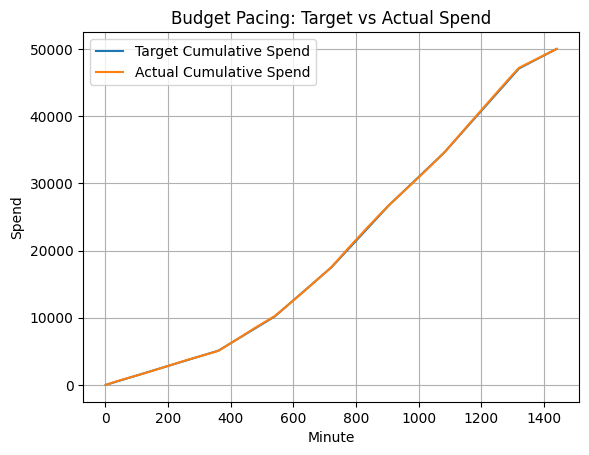

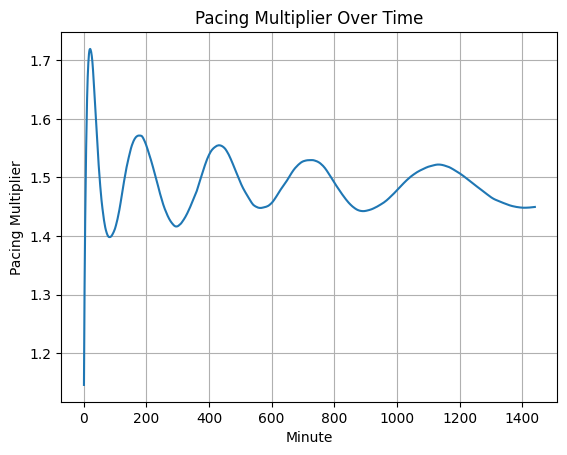

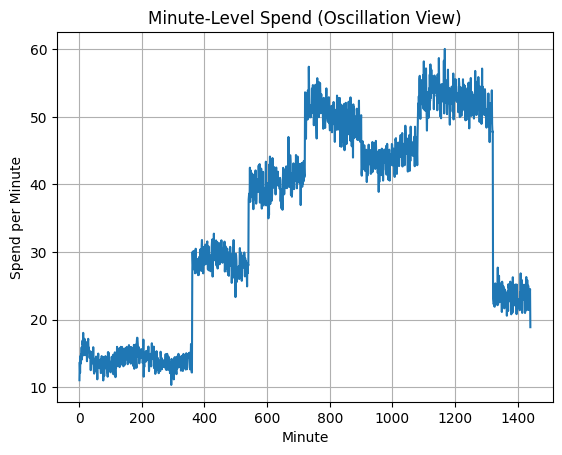

In [114]:
plot(out)

# Plot hourly spend curve matched to the demand curve

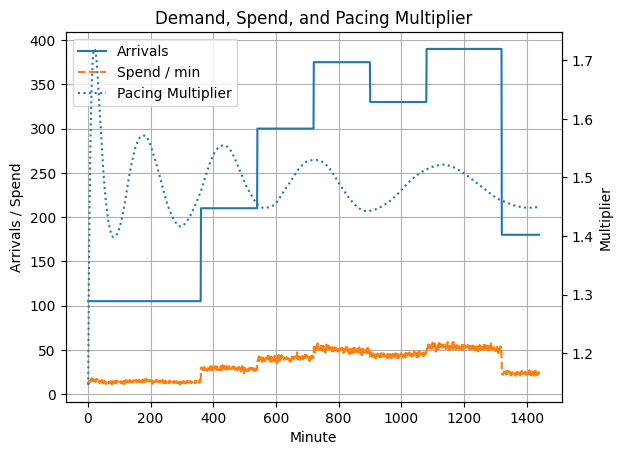

In [115]:
import matplotlib.pyplot as plt

ts = out["timeseries"]

t = [x["t_min"] for x in ts]
arrivals = [x["auction_arrivals"] for x in ts]
minute_spend = [x["minute_spend"] for x in ts]
mult = [x["pacing_mult"] for x in ts]

fig, ax1 = plt.subplots()

ax1.plot(t, arrivals, label="Arrivals")
ax1.plot(t, minute_spend, linestyle="--", label="Spend / min")
ax1.set_xlabel("Minute")
ax1.set_ylabel("Arrivals / Spend")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(t, mult, linestyle=":", label="Pacing Multiplier")
ax2.set_ylabel("Multiplier")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Demand, Spend, and Pacing Multiplier")
plt.show()

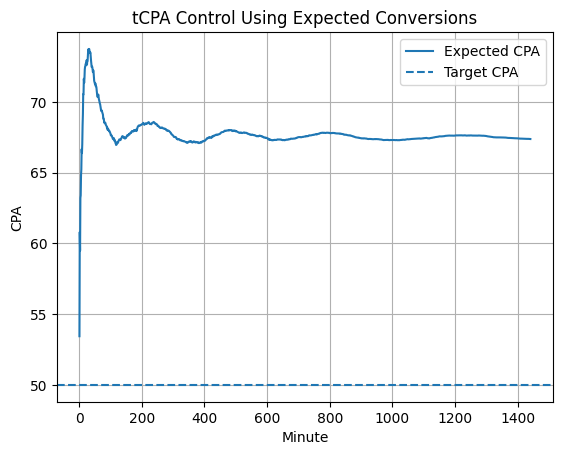

In [116]:
# CPA over time (expected vs observed)
est_cpa = [
    x["actual_cum_spend"] / max(1e-6, x["expected_conversions"])
    for x in ts
]

# expected_convs = [
#     x["expected_conversions"]
#     for x in ts
# ]

# print(expected_convs[:100])

plt.figure()
plt.plot(t, est_cpa, label="Expected CPA")
plt.axhline(tcpa_cfg.target_cpa, linestyle="--", label="Target CPA")
plt.xlabel("Minute")
plt.ylabel("CPA")
plt.title("tCPA Control Using Expected Conversions")
plt.legend()
plt.grid(True)
plt.show()

# Plot pCTR, pCVR and CPC

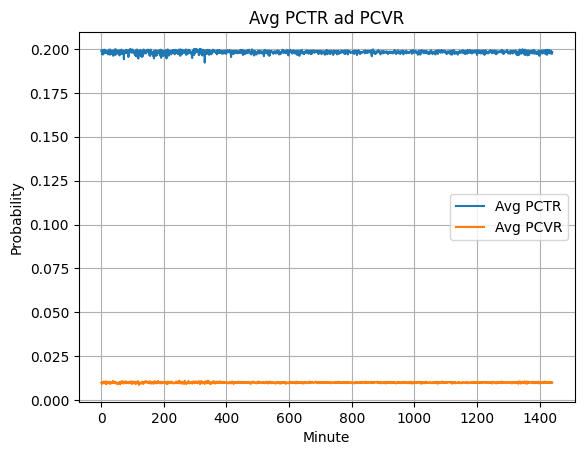

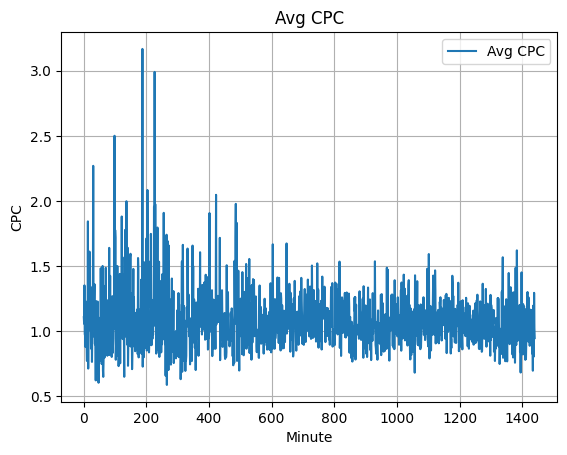

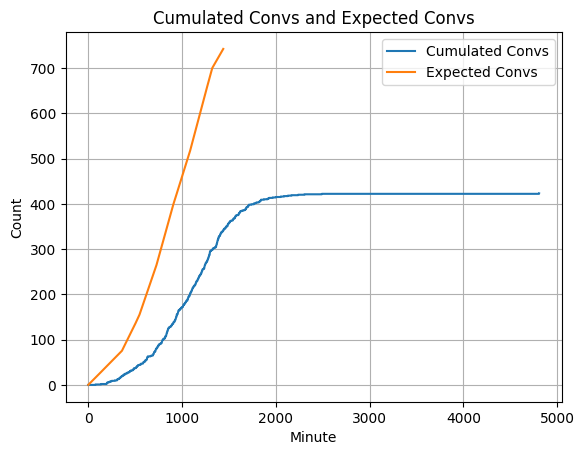

In [130]:
avg_pctrs = [
    x["avg_pctr"]
    for x in ts
]

avg_pcvrs = [
    x["avg_pcvr"]
    for x in ts
]

plt.figure()
plt.plot(t, avg_pctrs, label="Avg PCTR")
plt.plot(t, avg_pcvrs, label="Avg PCVR")
plt.xlabel("Minute")
plt.ylabel("Probability")
plt.title("Avg PCTR ad PCVR")
plt.legend()
plt.grid(True)
plt.show()


minute_cpc = [float(x["minute_spend"])/x["minute_clicks"] for x in ts]
plt.figure()
plt.plot(t, minute_cpc, label="Avg CPC")
plt.xlabel("Minute")
plt.ylabel("CPC")
plt.title("Avg CPC")
plt.legend()
plt.grid(True)
plt.show()

###
expected_conversions = [x["expected_conversions"] for x in ts]
# Convert defaultdict to list
# 1. Determine the required length (max key + 1)
size = max(conversion_events.keys()) + 1
# 2. Initialize with a placeholder 
cumulated_convs = [0] * size
# 3. Fill the list
cumulated_conv = 0

for i in range(size):
    cumulated_conv += conversion_events.get(i, 0)
    cumulated_convs[i] = cumulated_conv
t_conv = range(size)

plt.figure()
plt.plot(t_conv, cumulated_convs, label="Cumulated Convs")
plt.plot(t, expected_conversions, label="Expected Convs")
plt.xlabel("Minute")
plt.ylabel("Count")
plt.title("Cumulated Convs and Expected Convs")
plt.legend()
plt.grid(True)
plt.show()